<a href="https://colab.research.google.com/github/Gnissan-BIA/Assignments/blob/main/Project_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1 Data Collection

In [2]:
# Import Libraries
import pandas as pd


# Load Datasets
prices = pd.read_csv("/content/historical_stock_prices.csv")
stocks = pd.read_csv("/content/historical_stocks.csv")

# Display data
print ("Historical Stock Prices\n")
print (prices.head())
print ("\nHistorical Stocks\n")
print (stocks.head())

Historical Stock Prices

  ticker   open  close  adj_close    low   high     volume        date
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900.0  2013-05-08
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800.0  2013-05-09
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100.0  2013-05-10
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400.0  2013-05-13
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100.0  2013-05-14

Historical Stocks

  ticker exchange                                    name             sector  \
0    PIH   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
1  PIHPP   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
2   TURN   NASDAQ                180 DEGREE CAPITAL CORP.            FINANCE   
3   FLWS   NASDAQ                 1-800 FLOWERS.COM, INC.  CONSUMER SERVICES   
4   FCCY   NASDAQ           1ST CONSTITUTION BANCORP (NJ)            FINANCE   

                     industry  
0  PROPERTY-CASU

#2 Data Cleaning

Missing values

In [3]:
# Check for missing values
print(prices.isnull().sum())
print(stocks.isnull().sum())

# Fill missing categorical values in Stocks df with mode
for col in stocks.select_dtypes(include='object').columns:
    if stocks[col].isnull().sum() > 0:
        stocks[col].fillna(stocks[col].mode()[0], inplace=True)

# Check for missing values after imputation
print("Cleaned Stocks dataset")
print(stocks.isnull().sum())

ticker       0
open         0
close        0
adj_close    1
low          1
high         1
volume       1
date         1
dtype: int64
ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64
Cleaned Stocks dataset
ticker      0
exchange    0
name        0
sector      0
industry    0
dtype: int64


/tmp/ipykernel_2446/1512307166.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stocks[col].fillna(stocks[col].mode()[0], inplace=True)


Remove Duplicates

In [4]:
prices.drop_duplicates(inplace=True)

Convert Date Column and set it as index

In [8]:
prices['date'] = pd.to_datetime(prices['date'], errors='coerce')
prices.dropna(subset=['date'], inplace=True)
prices.set_index('date', inplace=True)

print(prices.head())

           ticker   open  close  adj_close    low   high     volume
date                                                               
2013-05-08    AHH  11.50  11.58   8.493155  11.25  11.68  4633900.0
2013-05-09    AHH  11.66  11.55   8.471151  11.50  11.66   275800.0
2013-05-10    AHH  11.55  11.60   8.507822  11.50  11.60   277100.0
2013-05-13    AHH  11.63  11.65   8.544494  11.55  11.65   147400.0
2013-05-14    AHH  11.60  11.53   8.456484  11.50  11.60   184100.0


#3 Data Segmentation by Decade

In [9]:
# New column "decade"
prices["year"] = prices.index.year
prices["decade"] = (prices["year"] // 10) * 10
print(prices.head())

#Group by Decade
decades = dict(tuple(prices.groupby('decade')))



           ticker   open  close  adj_close    low   high     volume  year  \
date                                                                        
2013-05-08    AHH  11.50  11.58   8.493155  11.25  11.68  4633900.0  2013   
2013-05-09    AHH  11.66  11.55   8.471151  11.50  11.66   275800.0  2013   
2013-05-10    AHH  11.55  11.60   8.507822  11.50  11.60   277100.0  2013   
2013-05-13    AHH  11.63  11.65   8.544494  11.55  11.65   147400.0  2013   
2013-05-14    AHH  11.60  11.53   8.456484  11.50  11.60   184100.0  2013   

            decade  
date                
2013-05-08    2010  
2013-05-09    2010  
2013-05-10    2010  
2013-05-13    2010  
2013-05-14    2010  


#4 Exploratory Data Analysis by Decade

Merge datasets

In [10]:
merged = pd.merge(prices, stocks, on='ticker')
print(merged.head())

  ticker   open  close  adj_close    low   high     volume  year  decade  \
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900.0  2013    2010   
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800.0  2013    2010   
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100.0  2013    2010   
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400.0  2013    2010   
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100.0  2013    2010   

  exchange                             name   sector     industry  
0     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  
1     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  
2     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  
3     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  
4     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  


Summary statistics by decade

In [13]:
for decade, df in decades.items():
    print(f"\nDecade: {decade}")
    print(df[['open','high','low','close','volume']].describe())


Decade: 1970
             open        high         low       close         volume
count  532.000000  532.000000  532.000000  532.000000     532.000000
mean     0.616663    0.673096    0.612666    0.612666   10431.954887
std      0.417561    0.446445    0.416452    0.416452   17883.691861
min      0.158958    0.177659    0.130906    0.130906     100.000000
25%      0.243112    0.289864    0.243112    0.243112     700.000000
50%      0.504924    0.570378    0.504924    0.504924    3700.000000
75%      0.795256    0.893436    0.795256    0.795256   12400.000000
max      1.656120    1.786012    1.656120    1.656120  170400.000000

Decade: 1980
               open          high           low         close        volume
count  15675.000000  15675.000000  15675.000000  15675.000000  1.567500e+04
mean       6.024242      6.120690      5.959942      6.027500  5.937876e+06
std        5.584179      5.644886      5.526893      5.591421  1.947980e+07
min        0.124128      0.125867      0.123261

Visualizations

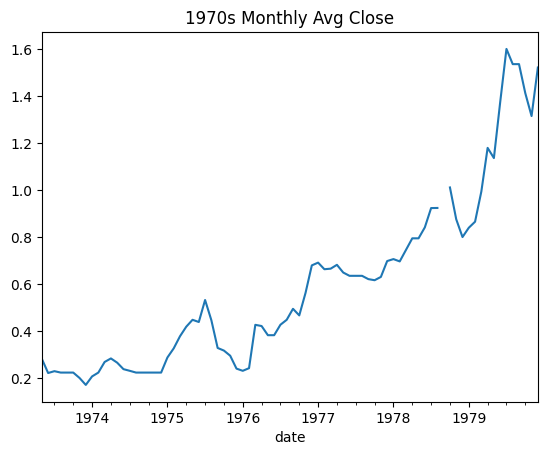

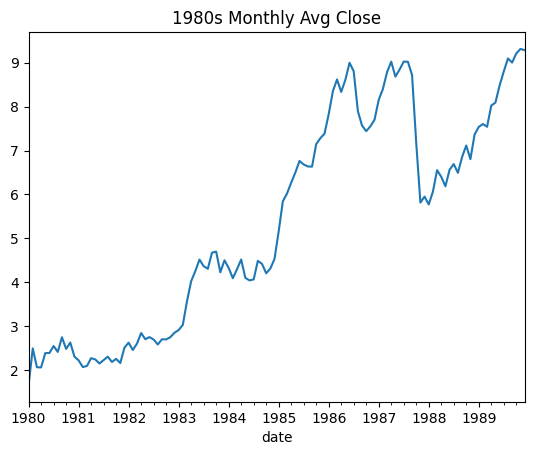

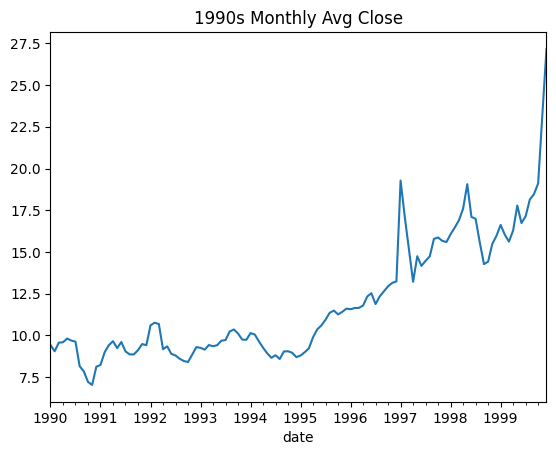

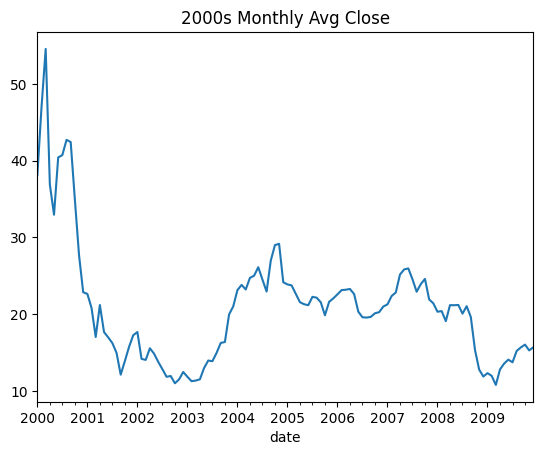

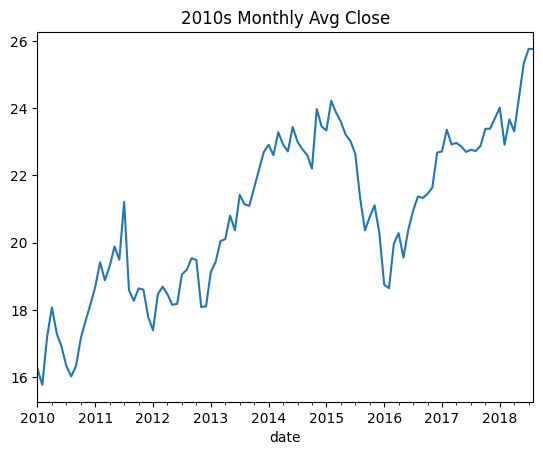

In [16]:
#Monthly Average Close (Time Series)
import matplotlib.pyplot as plt

for decade, df in decades.items():
    monthly = df['close'].resample('ME').mean()
    monthly.plot(title=f"{decade}s Monthly Avg Close")
    plt.show()

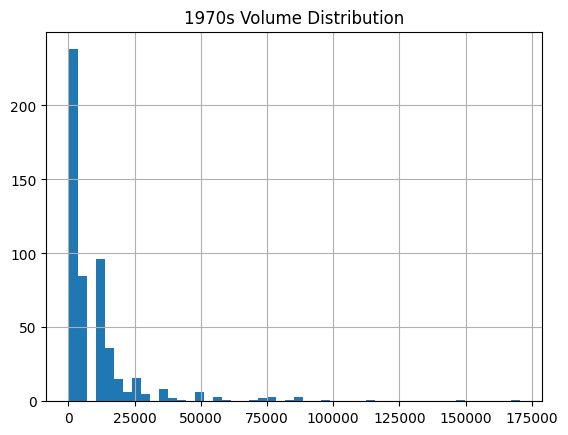

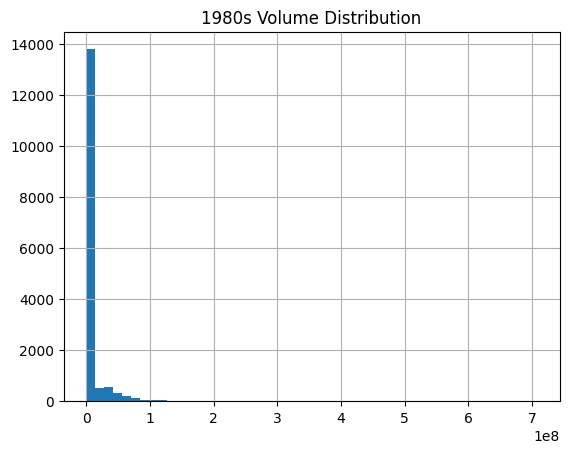

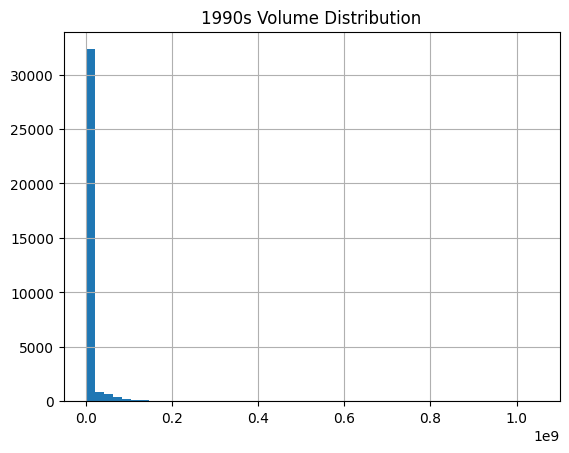

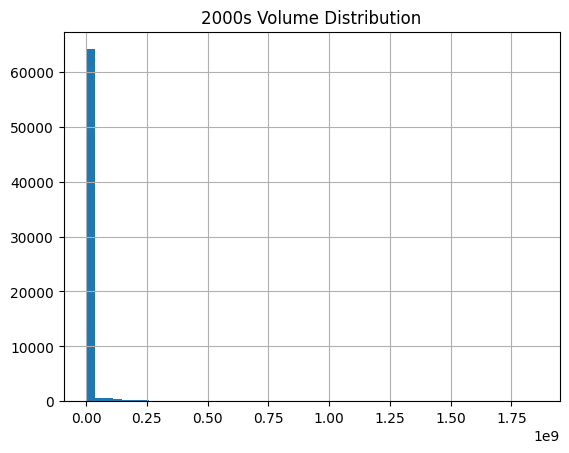

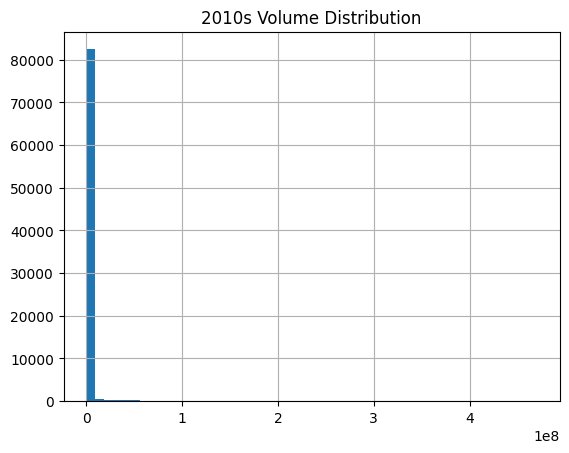

In [17]:
#Volume Distribution (Histogram)
for decade, df in decades.items():
    df['volume'].hist(bins=50)
    plt.title(f"{decade}s Volume Distribution")
    plt.show()


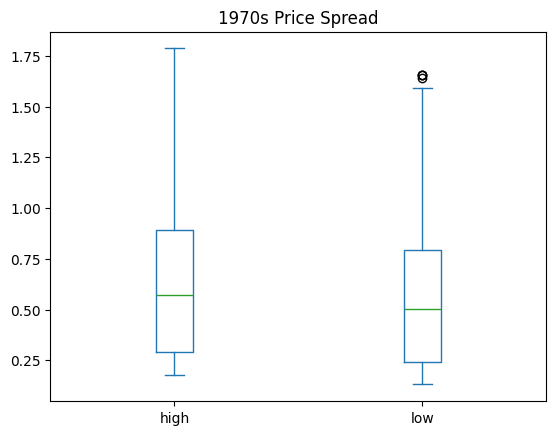

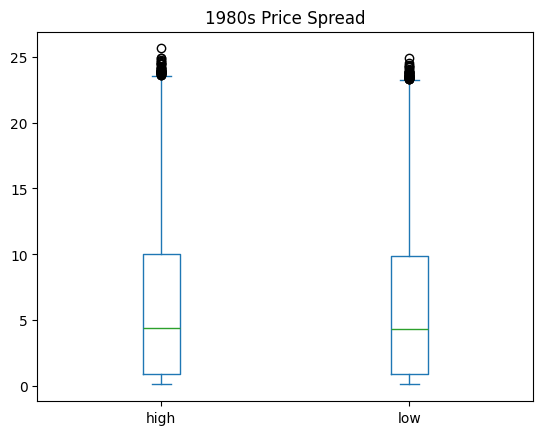

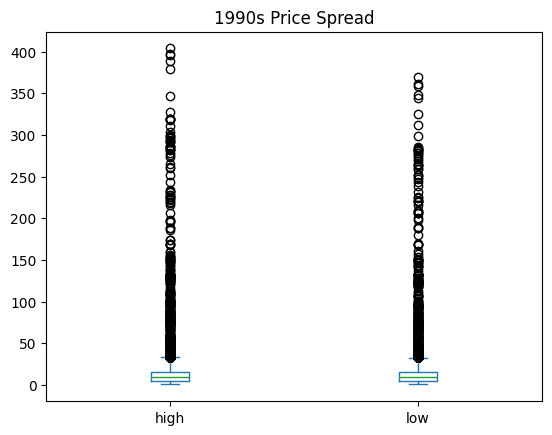

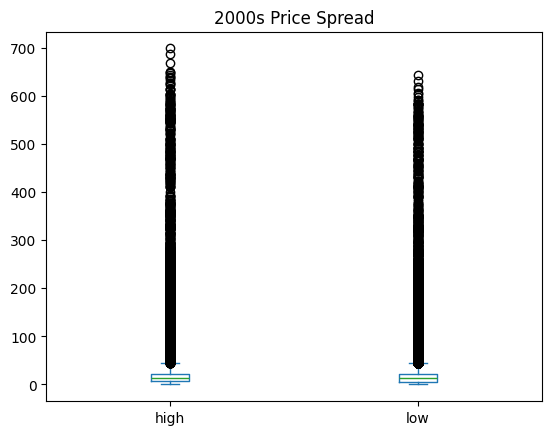

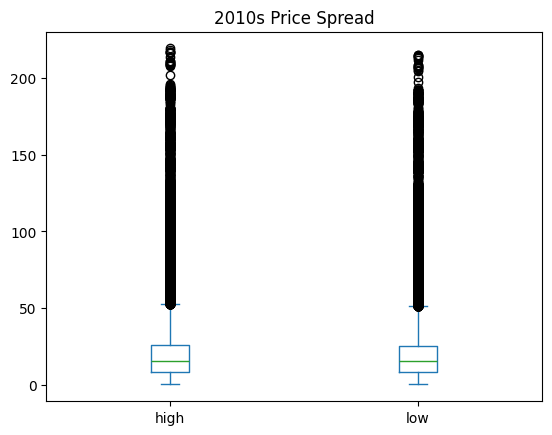

In [18]:
#Price Spread (Box Plot)
for decade, df in decades.items():
    df[['high','low']].plot(kind='box')
    plt.title(f"{decade}s Price Spread")
    plt.show()


#Comparative Analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sort data
prices = prices.sort_index()



# 1. Mean, Median, Std by Decade


In [19]:
decade_summary = prices.groupby("decade").agg(
    mean_close=("close", "mean"),
    median_close=("close", "median"),
    mean_open=("open", "mean"),
    median_open=("open", "median"),
    std_close=("close", "std"),
    mean_volume=("volume", "mean"),
    median_volume=("volume", "median"),
    max_close=("close", "max"),
    min_close=("close", "min"),
    max_volume=("volume", "max"),
    min_volume=("volume", "min")
)

# Difference between mean and median
decade_summary["mean_median_difference"] = (
    decade_summary["mean_close"] - decade_summary["median_close"]
)

print(decade_summary)

        mean_close  median_close  mean_open  median_open  std_close  \
decade                                                                
1970      0.612666      0.504924   0.616663     0.504924   0.416452   
1980      6.027500      4.320000   6.024242     4.320000   5.591421   
1990     12.604738      9.734788  12.598104     9.734788  15.456118   
2000     20.621823     13.190000  20.643426    13.190000  39.829767   
2010     20.991120     15.590000  20.991924    15.590000  20.889764   

         mean_volume  median_volume   max_close  min_close    max_volume  \
decade                                                                     
1970    1.043195e+04         3700.0    1.656120   0.130906  1.704000e+05   
1980    5.937876e+06        35400.0   25.625000   0.123261  7.080864e+08   
1990    5.254851e+06        58400.0  381.399323   0.462054  1.047620e+09   
2000    6.405028e+06        88600.0  666.808899   0.010000  1.855410e+09   
2010    2.723445e+06       156400.0  217.58000

# 2. Mean Prices Across Decades

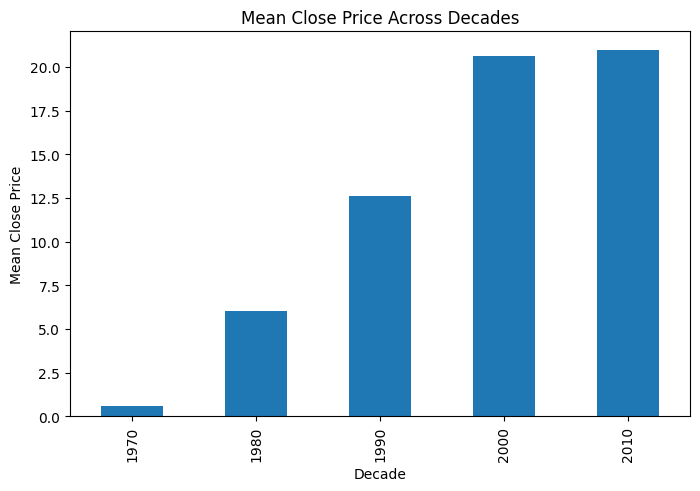

In [20]:
decade_summary["mean_close"].plot(kind="bar", figsize=(8,5))
plt.title("Mean Close Price Across Decades")
plt.xlabel("Decade")
plt.ylabel("Mean Close Price")
plt.show()

# 3. Median vs Mean Differences

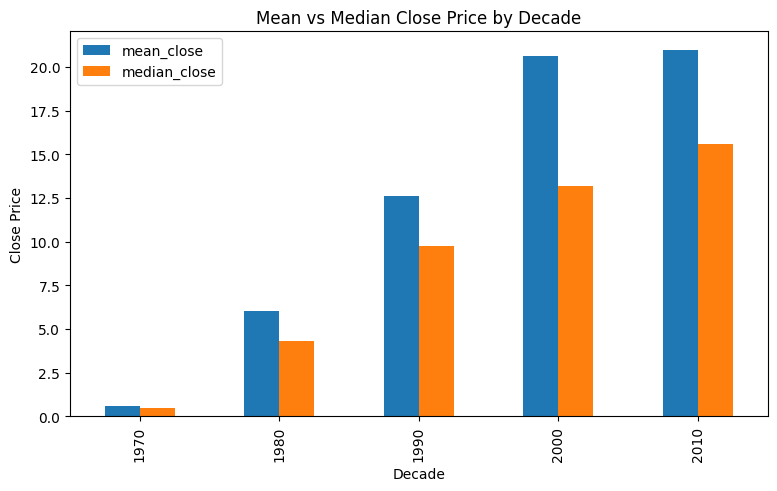

In [21]:
decade_summary[["mean_close", "median_close"]].plot(kind="bar", figsize=(9,5))
plt.title("Mean vs Median Close Price by Decade")
plt.xlabel("Decade")
plt.ylabel("Close Price")
plt.show()

# 4. Standard Deviation / Volatility

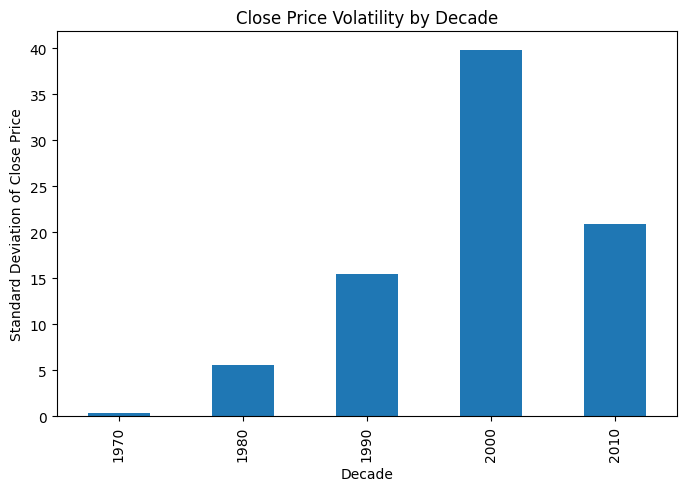

In [22]:
decade_summary["std_close"].plot(kind="bar", figsize=(8,5))
plt.title("Close Price Volatility by Decade")
plt.xlabel("Decade")
plt.ylabel("Standard Deviation of Close Price")
plt.show()

# 5. Volume Growth Trends

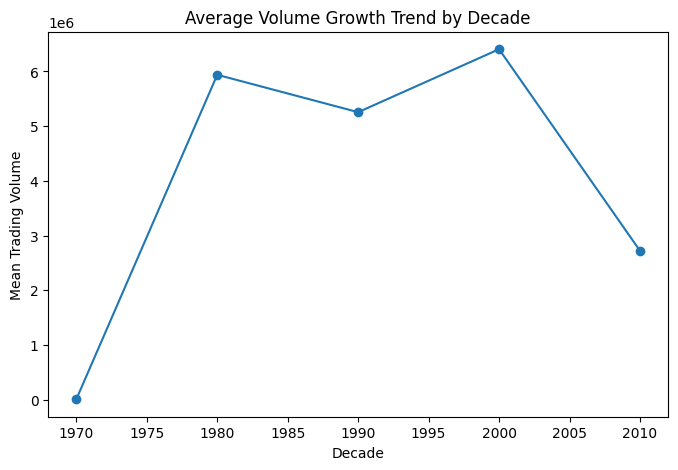

In [23]:
decade_summary["mean_volume"].plot(kind="line", marker="o", figsize=(8,5))
plt.title("Average Volume Growth Trend by Decade")
plt.xlabel("Decade")
plt.ylabel("Mean Trading Volume")
plt.show()

# 6. Outliers and Extreme Values
# Using IQR Method by Decade

In [24]:
outlier_results = []

for decade, df_decade in prices.groupby("decade"):
    Q1 = df_decade["close"].quantile(0.25)
    Q3 = df_decade["close"].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_decade[
        (df_decade["close"] < lower_bound) |
        (df_decade["close"] > upper_bound)
    ]

    outlier_results.append({
        "decade": decade,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers),
        "max_close": df_decade["close"].max(),
        "min_close": df_decade["close"].min()
    })

outlier_summary = pd.DataFrame(outlier_results)

print(outlier_summary)

   decade        Q1         Q3        IQR  lower_bound  upper_bound  \
0    1970  0.243112   0.795256   0.552144    -0.585105     1.623472   
1    1980  0.938616  10.000000   9.061384   -12.653460    23.592076   
2    1990  4.370370  15.856087  11.485717   -12.858205    33.084662   
3    2000  6.300000  21.600000  15.300000   -16.650000    44.550001   
4    2010  8.450000  25.900000  17.450000   -17.725000    52.074999   

   outlier_count   max_close  min_close  
0              4    1.656120   0.130906  
1             32   25.625000   0.123261  
2           1653  381.399323   0.462054  
3           4393  666.808899   0.010000  
4           5348  217.580002   0.320000  


# 7. Boxplot to Visualize Outliers

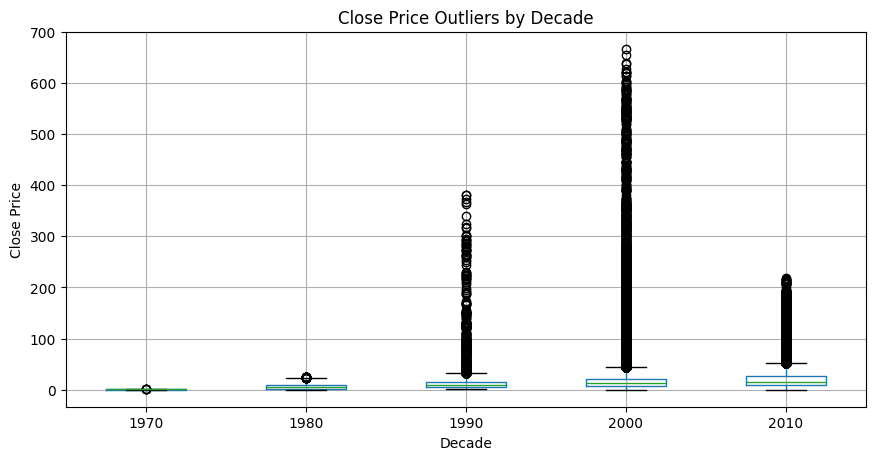

In [25]:
prices.boxplot(column="close", by="decade", figsize=(10,5))
plt.title("Close Price Outliers by Decade")
plt.suptitle("")
plt.xlabel("Decade")
plt.ylabel("Close Price")
plt.show()

# 8. Extreme Values: Top 10 Highest Close Prices

In [26]:
extreme_highs = prices.sort_values("close", ascending=False).head(10)

print("Top 10 Extreme High Close Prices:")
print(extreme_highs[["ticker", "close", "volume", "year", "decade"]])

Top 10 Extreme High Close Prices:
           ticker       close      volume  year  decade
date                                                   
2000-03-06   VIAV  666.808899   4242700.0  2000    2000
2000-03-07   VIAV  653.868042   5100600.0  2000    2000
2000-03-01   VIAV  639.078491   3724400.0  2000    2000
2000-03-03   VIAV  637.087585   2844600.0  2000    2000
2000-03-10   VIAV  627.986328   4660100.0  2000    2000
2000-03-02   VIAV  621.160400   3609500.0  2000    2000
2000-03-08   VIAV  621.160400   7499100.0  2000    2000
2000-03-09   VIAV  620.022766   4159600.0  2000    2000
2000-07-26   VIAV  618.600708  21002100.0  2000    2000
2000-07-21   VIAV  613.481201  14247500.0  2000    2000


# 9. Extreme Values: Top 10 Highest Volumes

In [27]:
extreme_volumes = prices.sort_values("volume", ascending=False).head(10)

print("Top 10 Extreme High Volume Values:")
print(extreme_volumes[["ticker", "close", "volume", "year", "decade"]])

Top 10 Extreme High Volume Values:
           ticker      close        volume  year  decade
date                                                    
2000-09-29   AAPL   1.839286  1.855410e+09  2000    2000
1997-08-06   AAPL   0.939732  1.047620e+09  1997    1990
1997-08-07   AAPL   1.042411  9.388596e+08  1997    1990
2008-01-23   AAPL  19.867144  8.432424e+08  2008    2000
1999-09-21   AAPL   2.473214  8.393896e+08  1999    1990
2007-01-09   AAPL  13.224286  8.373246e+08  2007    2000
2005-01-13   AAPL   4.985714  7.911792e+08  2005    2000
2007-01-10   AAPL  13.857142  7.382200e+08  2007    2000
1983-09-23   AAPL   0.433036  7.080864e+08  1983    1980
2004-10-14   AAPL   3.212857  6.921068e+08  2004    2000
